# HANNA dataset EDA by Khwezi Kunene


---

This dataset will explore the input files from  from https://github.com/dig-team/hanna-benchmark-asg:
  - hanna_stories_annotations.csv   (raw per-rater annotations)
  - hanna_metrics_scores_llm.csv    (per-story averaged scores + 72 metric scores)
  - hanna_llm_stories.csv   (the ai generated stories)

## Imports and Loading Data

In [2]:
!pip install pingouin

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 13.1 MB/s eta 0:00:00


In [56]:
!pip install wordcloud

In [57]:
import re
from collections import Counter
import warnings
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import pingouin as pg
import seaborn as sns
from scipy import stats
import ast
from wordcloud import WordCloud
warnings.filterwarnings("ignore")

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [20]:
ANNOTATIONS_FILE = "/content/drive/MyDrive/Colab Notebooks/Dissertation/HANNA/hanna_stories_annotations.csv"
METRICS_FILE = "/content/drive/MyDrive/Colab Notebooks/Dissertation/HANNA/hanna_metric_scores_llm.csv"
STORIES_FILE = "/content/drive/MyDrive/Colab Notebooks/Dissertation/HANNA/hanna_llm_stories.csv"

In [6]:
OUTPUT_DIR = Path("hanna_eda_plots")
OUTPUT_DIR.mkdir(exist_ok=True)

In [33]:
CRITERIA = ["Relevance", "Coherence", "Empathy", "Surprise", "Engagement", "Complexity",]
CRITERIA_LOWER = [c.lower() for c in CRITERIA]

MODEL_ORDER = ["Human", "BertGeneration", "CTRL", "Fusion","GPT", "GPT-2", "HINT", "RoBERTa", "TD-VAE", "XLNet", "Platypus2",]
PALETTE = sns.color_palette("tab10", n_colors=len(MODEL_ORDER))

## Helper functions


---

The helper functions will assist with managing the plots and getting stats like average sentence length, token information

- save() will save the plots generated
- type_token_ration() to measure lexical diversity. lexical diversity is calculated by $\frac{unique words}{total words}$ to determinne whether vocaulary is repetitve or diverse.
- avg_sentence_length() will compute the number of words per sentence
- flesch_reading_ease() will estimate how easy a text is to read (readability). This calculated by $206.835−1.015(\frac{words​}{sentences})− 84.6(\frac{syllables​}{words})$  The Flesch Reading Ease was developed by Rudolf Flesch to measure how easily a passage of English can be understood. It evaluates text based on sentence length (average number of words per sentence) and word complexity (average number of syllables per word)
- count_syllables() is to count syllables

In [8]:
def save(fig: plt.Figure, name: str) -> None:
    path = OUTPUT_DIR / f"{name}.png"
    fig.savefig(path, bbox_inches="tight")
    print(f"  Saved → {path}")
    plt.close(fig)

def type_token_ratio(text: str) -> float:
    """Lexical diversity: unique tokens / total tokens."""
    tokens = re.findall(r"\b\w+\b", text.lower())
    return len(set(tokens)) / len(tokens) if tokens else 0.0

def avg_sentence_length(text: str) -> float:
    """Average words per sentence (splits on . ! ?)."""
    sentences = [s.strip() for s in re.split(r"[.!?]+", text) if s.strip()]
    if not sentences:
        return 0.0
    lengths = [len(re.findall(r"\b\w+\b", s)) for s in sentences]
    return np.mean(lengths)

def flesch_reading_ease(text: str) -> float:
    """
    Flesch Reading Ease score (approx).
    Higher = easier to read (0–100 scale).
    """
    words = re.findall(r"\b\w+\b", text)
    sentences = [s for s in re.split(r"[.!?]+", text) if s.strip()]
    syllables = sum(_count_syllables(w) for w in words)
    nw, ns = len(words), len(sentences)
    if nw == 0 or ns == 0:
        return 0.0
    return 206.835 - 1.015 * (nw / ns) - 84.6 * (syllables / nw)

def _count_syllables(word: str) -> int:
    word = word.lower().rstrip("e")
    vowels = re.findall(r"[aeiouy]+", word)
    return max(1, len(vowels))

## Loading HANNA data

In [26]:
def load_data(
    annotations_path="hanna_stories_annotations.csv",
    stories_path="hanna_llm_stories.csv",
    metrics_path="hanna_metric_scores_llm.csv",
):
    print("Loading data ...") #to calm down

    ann = pd.read_csv(annotations_path)
    stories = pd.read_csv(stories_path)
    met = pd.read_csv(metrics_path)

    ann.columns = ann.columns.str.strip().str.lower().str.replace(" ", "_")
    stories.columns = stories.columns.str.strip().str.lower().str.replace(" ", "_")
    met.columns = met.columns.str.strip().str.lower().str.replace(" ", "_")

    print(f"Annotations : {ann.shape}")
    print(f"Stories     : {stories.shape}")
    print(f"Metrics     : {met.shape}")

    return ann, stories, met

## Step 1 - Score distributions per criterion


---
This section will answer the questions:
- What are the score distributions?
- Do humans score differently from machine stories?

In [73]:
def score_distributions(ann):
    print("\n[Step 1] Score distributions")

    story_scores = (ann.groupby("Story ID")[CRITERIA] .mean() .reset_index())

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))

    for ax, crit in zip(axes.flatten(), CRITERIA):
        sns.histplot(story_scores[crit],bins=15,kde=True,ax=ax)
        ax.set_title(crit)

    plt.tight_layout()
    plt.show()
    save(fig, "1_score_distributions")

    print(story_scores[CRITERIA].describe() .round(3))

    fig, ax = plt.subplots(figsize=(10,6))
    sns.boxplot(data=story_scores[CRITERIA])
    ax.set_title("Human Evaluation Score Distributions")
    plt.tight_layout()
    plt.show()
    save(fig, "1_boxplots")

    return story_scores

## Step 2 - Inter-rater agreement


---

Inter-rater agreement refers to the degree of consistency or consensus among multiple raters to ensure that the evaluations are consistent and reliable.
This section will demonstarte much annotators agree?

$0 \leq ICC \leq 1$

| ICC      | Agreement |
| -------- | --------- |
| <0.4     | poor      |
| 0.4-0.6  | fair      |
| 0.6-0.75 | moderate  |
| >0.75    | good      |
| >0.9     | excellent |




In [52]:
def step2_inter_rater_agreement(ann):
    print("\n[Step 2] Rating agreement")

    rows = []

    for crit in CRITERIA:
        disagreement = ( ann.groupby("Story ID")[crit] .std())
        rows.append({"Criterion": crit, "Mean_SD": disagreement.mean(), "Median_SD": disagreement.median(),})

    agreement_df = pd.DataFrame(rows)
    fig, ax = plt.subplots(figsize=(8,5))
    sns.barplot(data=agreement_df, x="Criterion", y="Mean_SD", ax=ax,)

    ax.set_ylabel("Average annotator disagreement")
    plt.tight_layout()

    save(fig, "2_agreement")

    print(agreement_df)

    return agreement_df

## Step 3 - Score correlations across criteria


---

This section will examine the relationships between relevance, coherence, empathy, surprise, engagement and complexity.

- Spearman Correlation: Measures the relationship. Spearman is used because the human scores are ordinal (they are based on the likert scale values between 1 to 5). If coherence is high then engagement will be high.
| Value | Meaning          |
| ----- | ---------------- |
| 1     | perfect positive |
| 0     | none             |
| -1    | perfect negative |
- Kendall Tau: Measures the ranking agreement between humans and machine (AI), uses the same scale as spearman


In [61]:
def score_correlations(story_scores):
    print("\n[Step 3] Criterion correlations")

    corr = story_scores[CRITERIA].corr(method="spearman" )

    fig, ax = plt.subplots( figsize=(8, 6))
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1, )

    sns.heatmap(corr,mask=mask, annot=True, cmap="RdYlGn",vmin=-1,vmax=1,center=0,ax=ax,)

    plt.tight_layout()
    plt.show()
    save(fig, "3_correlations")

    return corr

## Step 4 - Model level analysis

---

This section will compare model performance (in producing stories). The Kruskal-Wallis Test (type of hypothesis test) is done.


- $H_{0}$: all models have the same distribution
- $H_{1}$: atleast one model has a different distribution

$H$ statistic will measure the strength of difference between the distributions

$p$-value is the probability that differences occurred by chance


| Value | Meaning              |
| ----- | ----------------     |
| <0.05	| significant          |
| <0.01 | highly significant   |
| <0.001| very strong evidence |


This section will answer the the questions:

- To determine which textual properties make stories score high or low.
- Do longer stories get higher scores?
- Do readble stories get higher empathy or coherence scores?


In [62]:
def model_analysis(ann):
    print("\n[Step 4] Model analysis")

    model_means = (ann.groupby("Model")[CRITERIA].mean().sort_values("Engagement", ascending=False))

    fig, ax = plt.subplots(figsize=(10, 6))

    sns.heatmap(model_means, annot=True, cmap="RdYlGn",ax=ax,)

    plt.tight_layout()
    plt.show()
    save(fig, "4_model_heatmap")

    print(model_means)

    return model_means

## Step 5 - Lexical Features

In [39]:
def lexical_features(stories):
    print("\n[Step 5] Lexical analysis")

    stories["word_count"] = (stories["Story"] .astype(str).str.split().str.len())
    stories["char_count"] = (stories["Story"].astype(str).str.len() )
    stories["ttr"] = (stories["Story"] .astype(str).apply(type_token_ratio))
    stories["avg_sent_len"] = (stories["Story"] .astype(str).apply(avg_sentence_length))

    stories["flesch"] = (stories["Story"].astype(str).apply(flesch_reading_ease))
    lexical_cols = ["word_count", "char_count", "ttr", "avg_sent_len", "flesch",]

    print(stories[lexical_cols].describe().round(3))

    return stories

## Step 6 - Prompt Diversity

---
This section will answer the questions:
- Are some prompts easier than others


In [65]:
def prompt_diversity(stories):
    print("\n[Step 6] Prompt analysis")

    stories["prompt_length"] = ( stories["Prompt"] .astype(str)  .str.split() .str.len())
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.histplot(stories["prompt_length"], bins=20, kde=True, ax=ax,)

    plt.tight_layout()
    plt.show()
    save(fig, "6_prompt_lengths")

    all_text = " ".join( stories["Prompt"] .astype(str) )

    wc = WordCloud(width=1200, height=600,background_color="white", ).generate(all_text)

    fig, ax = plt.subplots( figsize=(12, 6))

    ax.imshow(wc)
    ax.axis("off")
    plt.show()

    save(fig, "6_prompt_wordcloud")

## Step 7 - Auto metric vs human score correlation


---



To determine which automatic metrics best match human judgement

In [42]:
def metric_correlations(met):
    print("\n[Step 7] Automatic metrics")

    metric_cols = [c for c in met.columns if c not in ["Model"]]
    metric_summary = []

    for col in metric_cols:
        try:
            vals = met[col].apply(ast.literal_eval)
            flattened = np.concatenate(vals.values)
            metric_summary.append( {"Metric": col,"Mean": np.mean(flattened), "Std": np.std(flattened),})

        except Exception:
            continue

    summary_df = (pd.DataFrame(metric_summary).sort_values("Mean", ascending=False))
    print(summary_df.head(20))

    return summary_df

## Run full EDA

In [31]:
annotations = pd.read_csv( "/content/drive/MyDrive/Colab Notebooks/Dissertation/HANNA/hanna_stories_annotations.csv")
story = pd.read_csv( "/content/drive/MyDrive/Colab Notebooks/Dissertation/HANNA/hanna_llm_stories.csv")
metrics = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Dissertation/HANNA/hanna_metric_scores_llm.csv")

print("\nANNOTATION COLUMNS")
print(annotations.columns.tolist())

print("\nSTORY COLUMNS")
print(story.columns.tolist())

print("\nMETRIC COLUMNS")
print(metrics.columns.tolist())


ANNOTATION COLUMNS
['Story ID', 'Prompt', 'Human', 'Story', 'Model', 'Relevance', 'Coherence', 'Empathy', 'Surprise', 'Engagement', 'Complexity', 'Worker ID', 'Assignment ID', 'Work time in seconds', 'Name']

STORY COLUMNS
['Unnamed: 0', 'Prompt', 'Human', 'Story', 'Model']

METRIC COLUMNS
['Model', 'Relevance', 'Coherence', 'Empathy', 'Surprise', 'Engagement', 'Complexity', 'BLEU Ξ§', 'ROUGE-1 Recall Ξ§', 'ROUGE-1 Precision Ξ§', 'ROUGE-1 F-Score Ξ§', 'ROUGE-2 Recall Ξ§', 'ROUGE-2 Precision Ξ§', 'ROUGE-2 F-Score Ξ§', 'ROUGE-3 Recall Ξ§', 'ROUGE-3 Precision Ξ§', 'ROUGE-3 F-Score Ξ§', 'ROUGE-4 Recall Ξ§', 'ROUGE-4 Precision Ξ§', 'ROUGE-4 F-Score Ξ§', 'ROUGE-L Recall Ξ§', 'ROUGE-L Precision Ξ§', 'ROUGE-L F-Score Ξ§', 'ROUGE-W-1.2 Recall Ξ§', 'ROUGE-W-1.2 Precision Ξ§', 'ROUGE-W-1.2 F-Score Ξ§', 'ROUGE-S* Recall Ξ§', 'ROUGE-S* Precision Ξ§', 'ROUGE-S* F-Score Ξ§', 'ROUGE-SU* Recall Ξ§', 'ROUGE-SU* Precision Ξ§', 'ROUGE-SU* F-Score Ξ§', 'METEOR Ξ§', 'chrF Ξ§', 'CIDEr Ξ§', 'ROUGE-WE-3 Recal

In [32]:
display(annotations.head(2))
display(story.head(2))
display(metrics.head(2))

,Story ID,Prompt,Human,Story,Model,Relevance,Coherence,Empathy,Surprise,Engagement,Complexity,Worker ID,Assignment ID,Work time in seconds,Name
0,0,When you die the afterlife is an arena where y...,"3,000 years have I been fighting. Every mornin...","3,000 years have I been fighting. Every mornin...",Human,4,4,3,2,4,4,A2VE5IV9OD2SK1,3X87C8JFVHIT235KQ4UTS8264I6SQJ,579.0,NaN
1,0,When you die the afterlife is an arena where y...,"3,000 years have I been fighting. Every mornin...","3,000 years have I been fighting. Every mornin...",Human,5,5,1,3,4,1,A1IZ4NX41GKU4X,3DR23U6WEGL5K0SU6D4J8W9EM9LTE7,82.0,none


,Unnamed: 0,Prompt,Human,Story,Model
0,0,When you die the afterlife is an arena where y...,"3,000 years have I been fighting. Every mornin...",Great! Let's get started. How would you like ...,Llama-7b
1,1,A new law is enacted that erases soldiers memo...,"“Dad, you 're on TV again !” I heard Eric 's v...","Sure, here is a story based on the prompt:\n\...",Llama-7b


,Model,Relevance,Coherence,Empathy,Surprise,Engagement,Complexity,BLEU Ξ§,ROUGE-1 Recall Ξ§,ROUGE-1 Precision Ξ§,...,ChatGPT EG 3,ChatGPT CX 3,ChatGPT AVG 3,ChatGPT RE 4,ChatGPT CH 4,ChatGPT EM 4,ChatGPT SU 4,ChatGPT EG 4,ChatGPT CX 4,ChatGPT AVG 4
0,Human,"[3.6666666666666665, 5.0, 4.666666666666667, 3...","[3.6666666666666665, 4.666666666666667, 4.6666...","[2.3333333333333335, 4.0, 4.0, 3.0, 3.0, 3.333...","[2.3333333333333335, 3.6666666666666665, 4.333...","[3.3333333333333335, 3.6666666666666665, 4.0, ...","[2.6666666666666665, 4.0, 4.333333333333333, 4...","[100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",...,"[1.6666666666666667, 3.0, 3.0, 3.0, 3.0, 3.0, ...","[2.0, 3.3333333333333335, 3.3333333333333335, ...","[1.9444444444444444, 2.8333333333333335, 2.833...","[4.666666666666667, 5.0, 4.0, 4.33333333333333...","[4.0, 4.0, 4.0, 4.0, 5.0, 4.0, 4.0, 4.0, 3.0, ...","[3.3333333333333335, 4.0, 4.0, 4.0, 4.0, 4.0, ...","[3.6666666666666665, 3.0, 3.6666666666666665, ...","[3.3333333333333335, 4.0, 4.0, 4.0, 3.0, 4.0, ...","[3.3333333333333335, 3.0, 3.3333333333333335, ...","[3.722222222222222, 3.8333333333333335, 3.8333..."
1,BertGeneration,"[1.6666666666666667, 3.0, 1.3333333333333333, ...","[3.6666666666666665, 2.6666666666666665, 2.333...","[2.6666666666666665, 2.6666666666666665, 1.0, ...","[1.3333333333333333, 2.0, 1.6666666666666667, ...","[2.6666666666666665, 2.6666666666666665, 1.333...","[2.6666666666666665, 2.6666666666666665, 1.333...","[1.4336111822, 1.4493826988, 0.1779090484, 0.1...","[0.38249, 0.24074, 0.16285, 0.13276, 0.40645, ...","[0.37054, 0.26639, 0.59259, 0.56771, 0.26923, ...",...,"[1.3333333333333333, 1.0, 1.0, 2.6666666666666...","[3.0, 1.6666666666666667, 2.6666666666666665, ...","[1.5555555555555554, 1.1666666666666667, 2.277...","[3.6666666666666665, 1.6666666666666667, 1.0, ...","[3.3333333333333335, 2.0, 1.0, 2.0, 1.33333333...","[4.0, 1.0, 1.0, 1.0, 1.0, 2.3333333333333335, ...","[2.6666666666666665, 1.0, 1.0, 1.3333333333333...","[3.5, 1.6666666666666667, 1.0, 2.0, 1.33333333...","[3.0, 2.3333333333333335, 1.0, 2.0, 1.0, 2.0, ...","[3.3611111111111107, 1.6111111111111114, 1.0, ..."



[Step 1] Score distributions


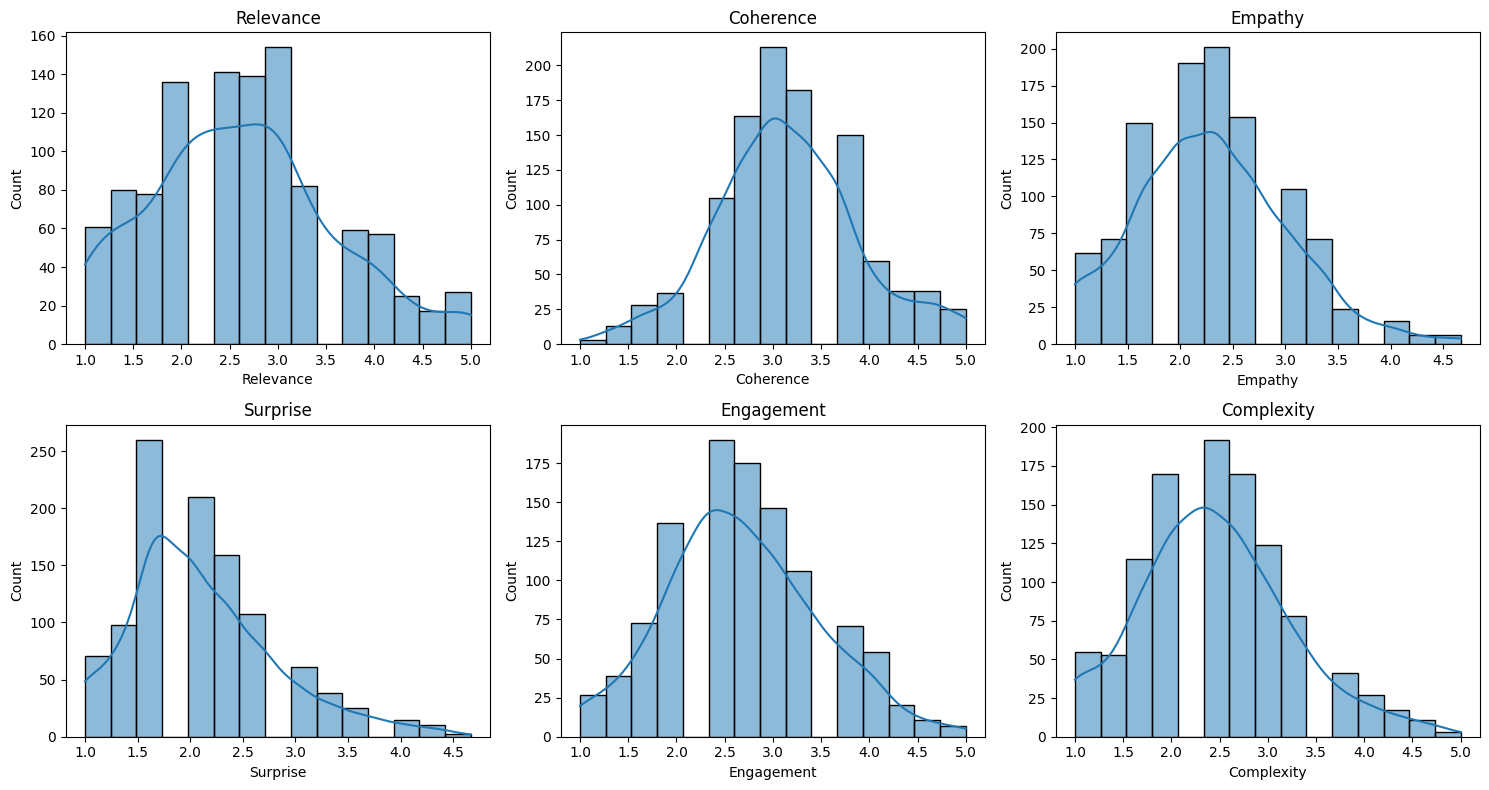

  Saved → hanna_eda_plots/1_score_distributions.png
       Relevance  Coherence   Empathy  Surprise  Engagement  Complexity
count   1056.000   1056.000  1056.000  1056.000    1056.000    1056.000
mean       2.625      3.150     2.295     2.107       2.676       2.452
std        0.955      0.752     0.719     0.704       0.795       0.788
min        1.000      1.000     1.000     1.000       1.000       1.000
25%        2.000      2.667     1.667     1.667       2.000       2.000
50%        2.667      3.000     2.333     2.000       2.667       2.333
75%        3.333      3.667     2.667     2.333       3.333       3.000
max        5.000      5.000     4.667     4.667       5.000       5.000

[Step 3] Criterion correlations


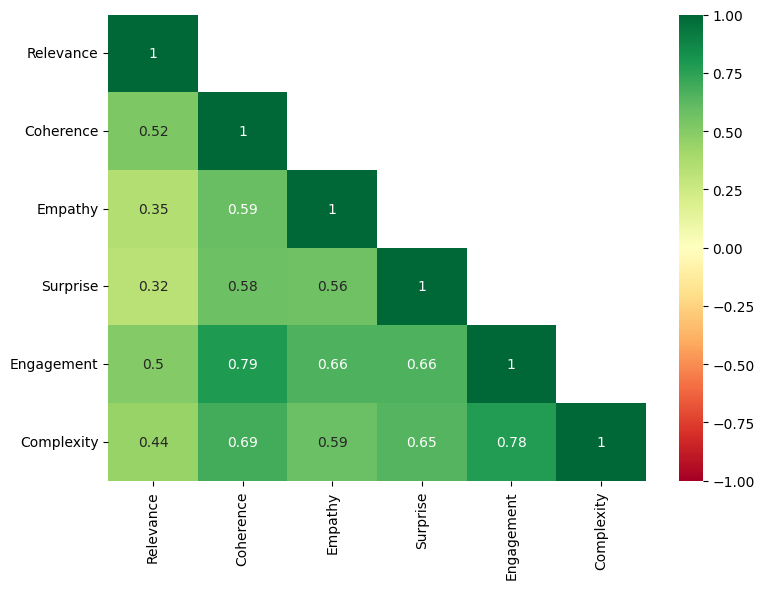

  Saved → hanna_eda_plots/3_correlations.png

[Step 4] Model analysis


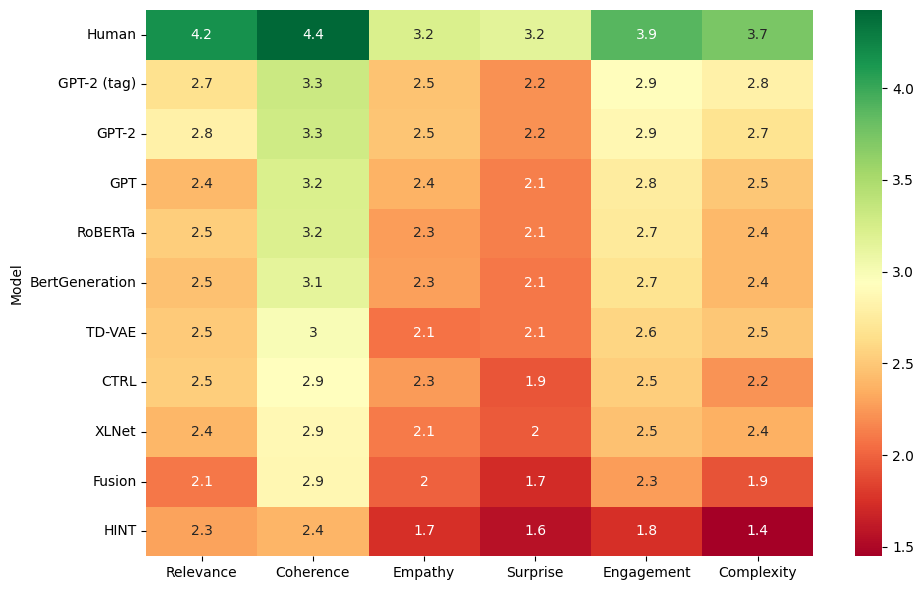

  Saved → hanna_eda_plots/4_model_heatmap.png
                Relevance  Coherence   Empathy  Surprise  Engagement  \
Model                                                                  
Human            4.170139   4.427083  3.222222  3.152778    3.881944   
GPT-2 (tag)      2.666667   3.312500  2.468750  2.215278    2.920139   
GPT-2            2.809028   3.288194  2.472222  2.208333    2.861111   
GPT              2.402778   3.218750  2.368056  2.128472    2.756944   
RoBERTa          2.541667   3.215278  2.267361  2.125000    2.739583   
BertGeneration   2.458333   3.142361  2.284722  2.090278    2.670139   
TD-VAE           2.506944   2.989583  2.072917  2.097222    2.586806   
CTRL             2.538194   2.927083  2.260417  1.934028    2.534722   
XLNet            2.392361   2.878472  2.100694  1.954861    2.458333   
Fusion           2.093750   2.864583  1.989583  1.718750    2.270833   
HINT             2.291667   2.381944  1.743056  1.555556    1.750000   

                C

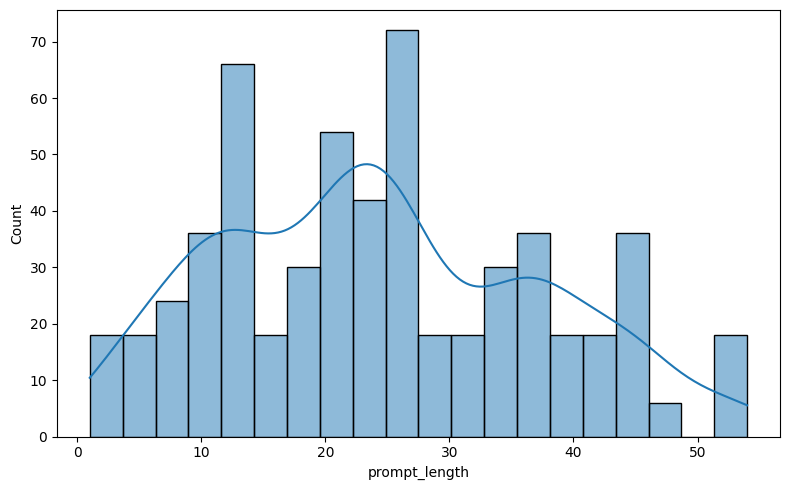

  Saved → hanna_eda_plots/6_prompt_lengths.png


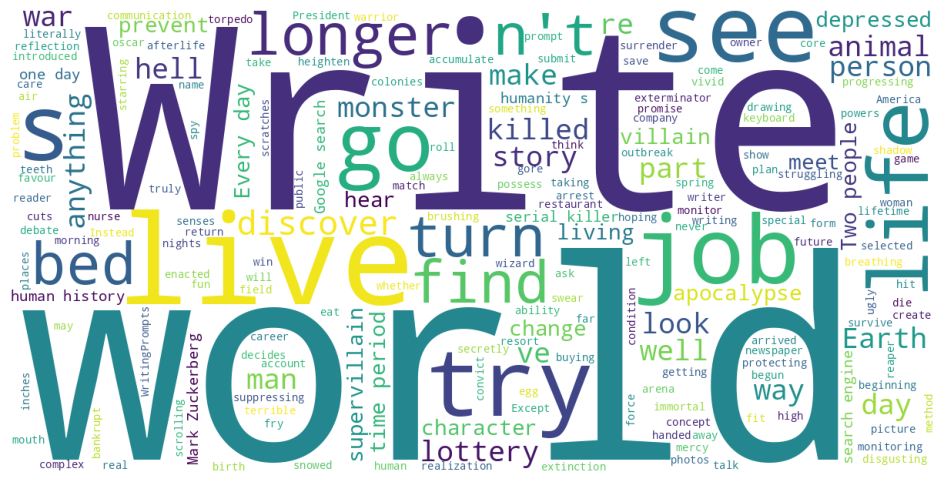

  Saved → hanna_eda_plots/6_prompt_wordcloud.png

[Step 7] Automatic metrics
                Metric        Mean         Std
63      Text length ¤§  306.620265  170.626022
32             chrF Ξ§   31.084209   24.231487
6              BLEU Ξ§    9.753056   28.544859
215     Llama-13B SU 3    3.527778    0.645348
203     Llama-13B CX 1    3.526515    0.698861
207     Llama-13B EM 2    3.341856    0.729288
200     Llama-13B EM 1    3.227286    0.838438
198     Llama-13B RE 1    3.211711    0.831805
79          Human 1 CH    3.210227    1.368383
103     Human Avg 2 CH    3.205019    0.936357
91          Human 3 CH    3.199811    1.360579
1            Coherence    3.149621    0.751348
210     Llama-13B CX 2    3.134628    0.787836
109     Human Avg 3 CH    3.124527    0.969895
97      Human Avg 1 CH    3.119318    0.935650
159  OrcaPlatypus SU 3    3.114804    0.836504
205     Llama-13B RE 2    3.103851    0.801441
214     Llama-13B EM 3    3.093434    0.726123
204    Llama-13B AVG 1    3.09

In [66]:
story_scores = score_distributions(annotations)
#icc_df = inter_rater_agreement(annotations)
corr = score_correlations(story_scores)
model_means = model_analysis(annotations)
stories = lexical_features(story)
prompt_diversity(stories)
metric_summary = metric_correlations(metrics)

## Interpretation


[Step 1] Score distributions


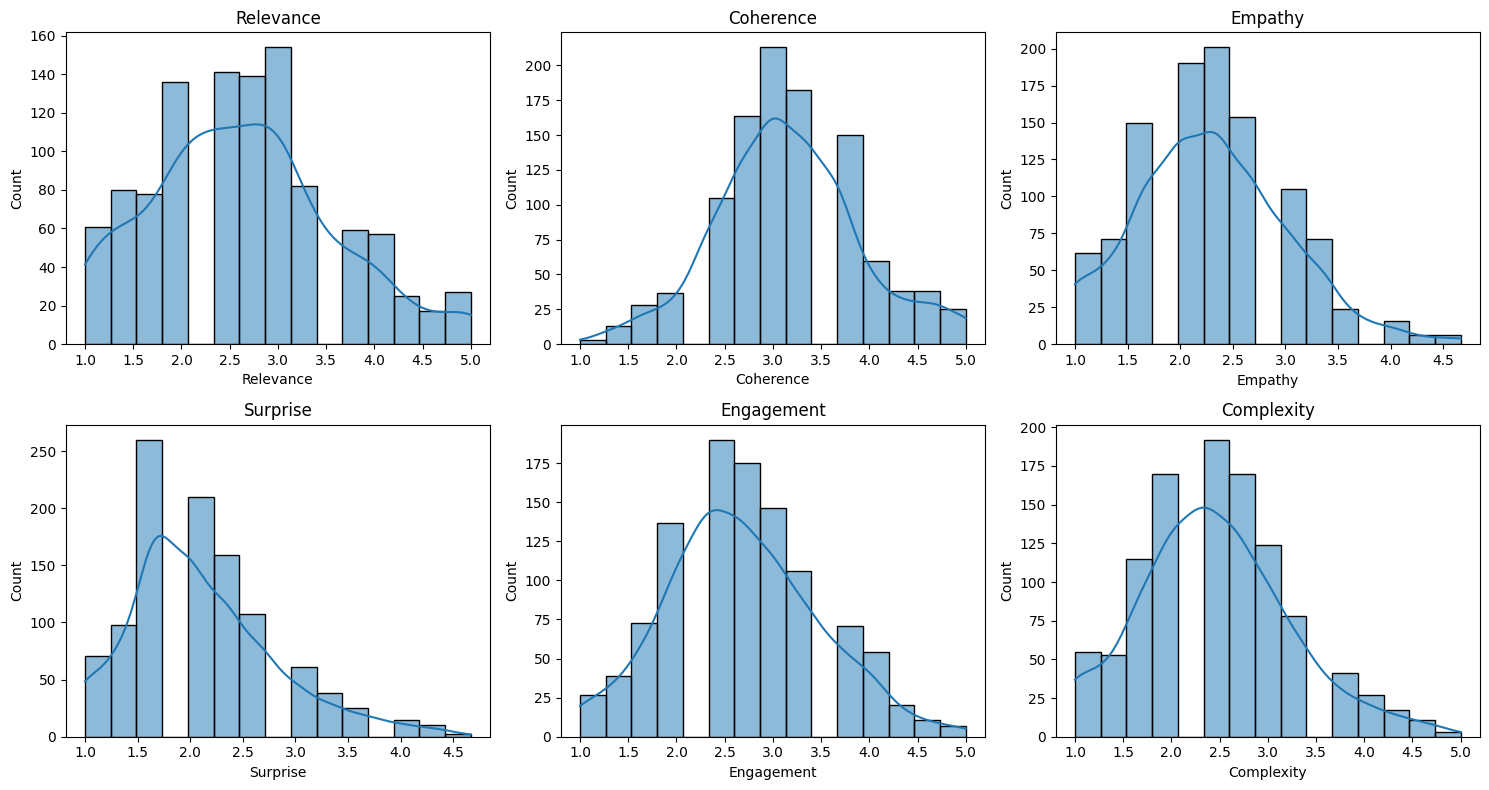

  Saved → hanna_eda_plots/1_score_distributions.png
       Relevance  Coherence   Empathy  Surprise  Engagement  Complexity
count   1056.000   1056.000  1056.000  1056.000    1056.000    1056.000
mean       2.625      3.150     2.295     2.107       2.676       2.452
std        0.955      0.752     0.719     0.704       0.795       0.788
min        1.000      1.000     1.000     1.000       1.000       1.000
25%        2.000      2.667     1.667     1.667       2.000       2.000
50%        2.667      3.000     2.333     2.000       2.667       2.333
75%        3.333      3.667     2.667     2.333       3.333       3.000
max        5.000      5.000     4.667     4.667       5.000       5.000


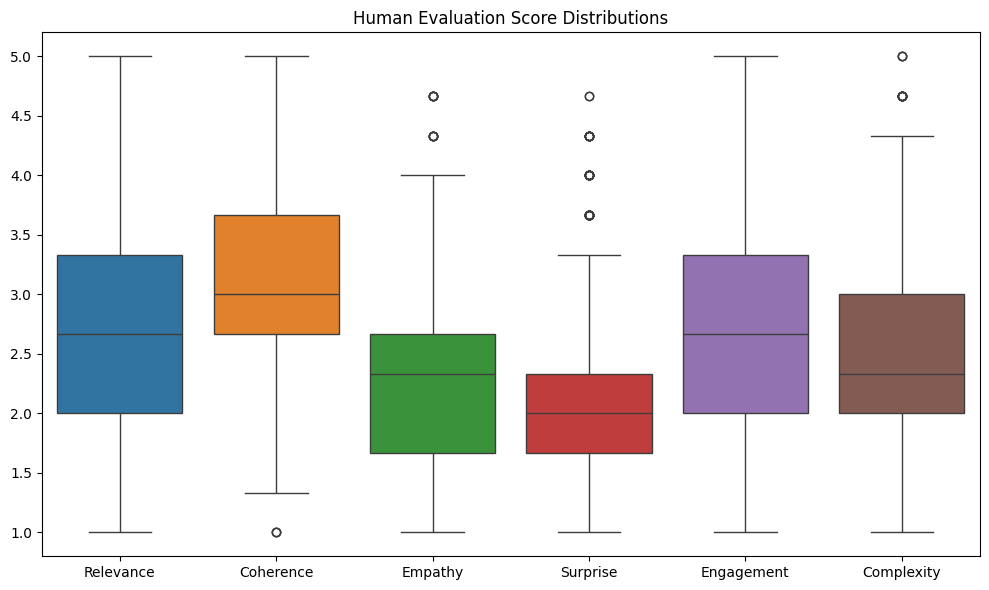

  Saved → hanna_eda_plots/1_boxplots.png


In [74]:
story_scores = score_distributions(annotations)

The highest-rated criterion is Coherence (3.15), indicating that stories generally maintain logical consistency and narrative flow. The lowest-rated criterion is Surprise (2.11), suggesting that both humans and language models struggle to generate highly novel or unexpected narrative developments.

The relatively low scores for Empathy (2.30) and Complexity (2.45) indicate that stories often lack emotional depth and sophisticated narrative structure.

Annotators consistently found stories insufficiently surprising, whereas relevance varied considerably across prompts and models.


[Step 3] Criterion correlations


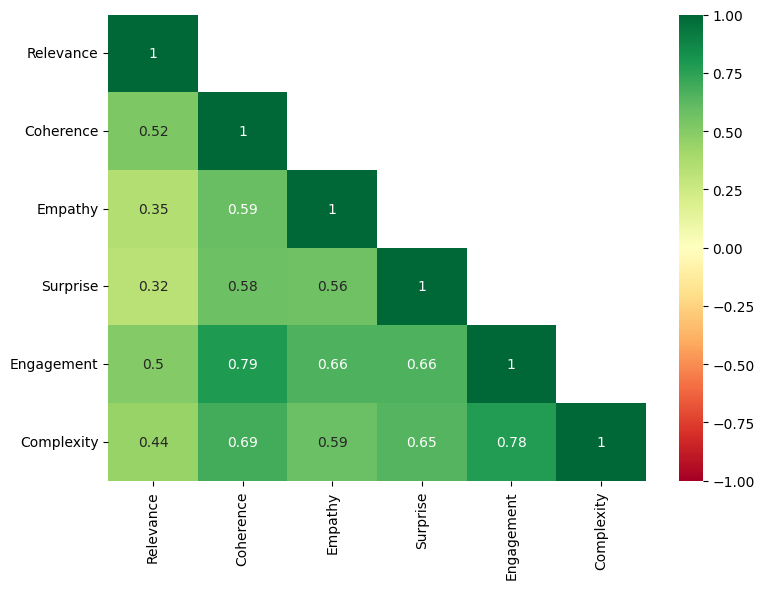

  Saved → hanna_eda_plots/3_correlations.png


In [68]:
corr = score_correlations(story_scores)

Coherence + Engagement have highest correlation -  Readers typically find coherent stories more engaging.

Relevance + Coherence - Stories that remain faithful to the prompt often maintain stronger narrative structure.

Empathy + Engagement - Emotionally resonant stories tend to keep readers invested.

Surprise - Surprise often shows weaker correlations because unexpected events may either enhance or disrupt narrative quality.


[Step 4] Model analysis


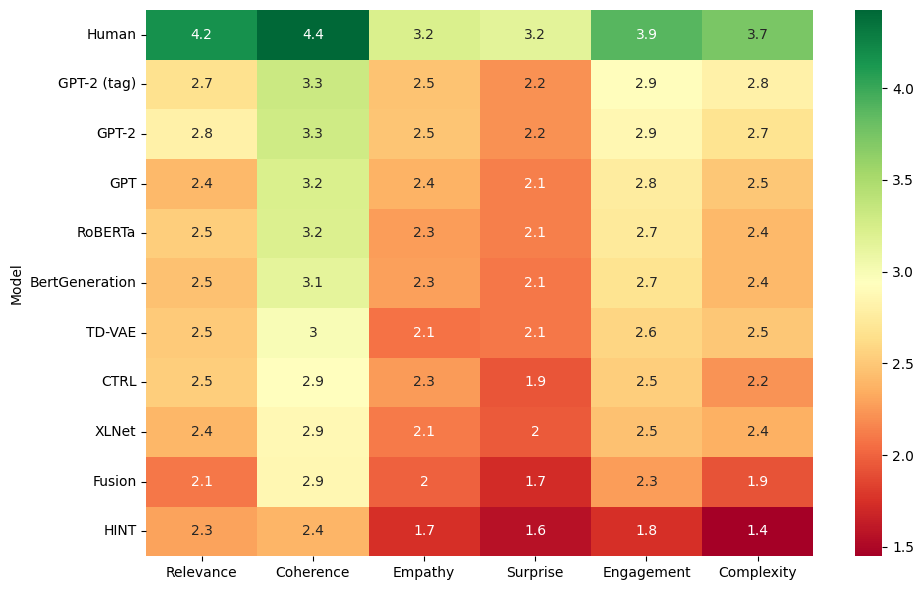

  Saved → hanna_eda_plots/4_model_heatmap.png
                Relevance  Coherence   Empathy  Surprise  Engagement  \
Model                                                                  
Human            4.170139   4.427083  3.222222  3.152778    3.881944   
GPT-2 (tag)      2.666667   3.312500  2.468750  2.215278    2.920139   
GPT-2            2.809028   3.288194  2.472222  2.208333    2.861111   
GPT              2.402778   3.218750  2.368056  2.128472    2.756944   
RoBERTa          2.541667   3.215278  2.267361  2.125000    2.739583   
BertGeneration   2.458333   3.142361  2.284722  2.090278    2.670139   
TD-VAE           2.506944   2.989583  2.072917  2.097222    2.586806   
CTRL             2.538194   2.927083  2.260417  1.934028    2.534722   
XLNet            2.392361   2.878472  2.100694  1.954861    2.458333   
Fusion           2.093750   2.864583  1.989583  1.718750    2.270833   
HINT             2.291667   2.381944  1.743056  1.555556    1.750000   

                C

In [69]:
model_means = model_analysis(annotations)

Humans outperform all automatic systems across all six dimensions. For my project this can motivate for traiing on human input

Best perfoming model was GPT-2. The complexity gap (difference) between human and GPT-2 is 0.93 which is an indication of the gap between human and uatomated gap story generation.

In [70]:
stories = lexical_features(story)


[Step 5] Lexical analysis
       word_count  char_count      ttr  avg_sent_len   flesch
count     576.000     576.000  576.000       576.000  576.000
mean      504.696    2930.429    0.487        18.217   61.709
std       143.001     849.580    0.056         3.428   10.412
min        16.000      83.000    0.319         7.186   31.708
25%       404.500    2324.000    0.454        16.139   55.205
50%       511.000    2945.000    0.484        18.144   61.550
75%       607.250    3576.250    0.515        20.234   68.699
max       807.000    4608.000    0.882        31.692  100.423


- Story length (word_count):
The stories generated are relatively short (on average)

- Type token ratio (ttr):
average of 0.487 which indicates a moderate vocabulary -> indicates lexical diversity

- Sentence Length (avg_sent_length):
18.2 words per sentence - long sentences
Longer sentences tend to be more descriptive and more complex

- Flesch Reading Ease:
The average score is 61.709 - which may indicate standard reading difficulty


[Step 6] Prompt analysis


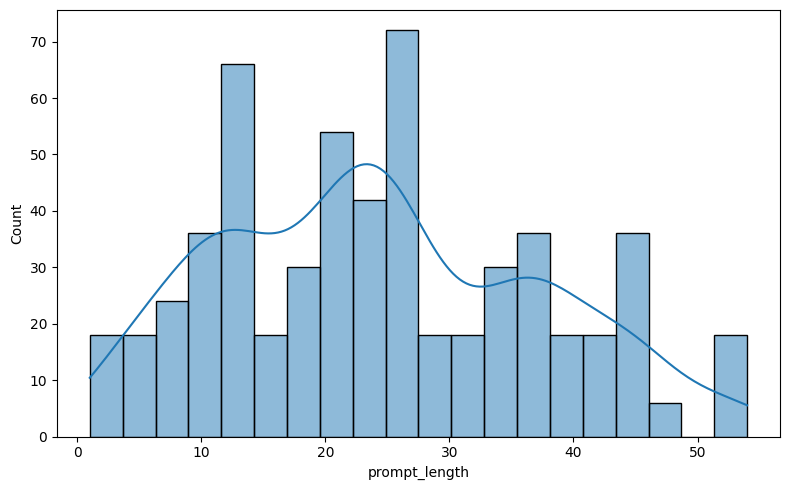

  Saved → hanna_eda_plots/6_prompt_lengths.png


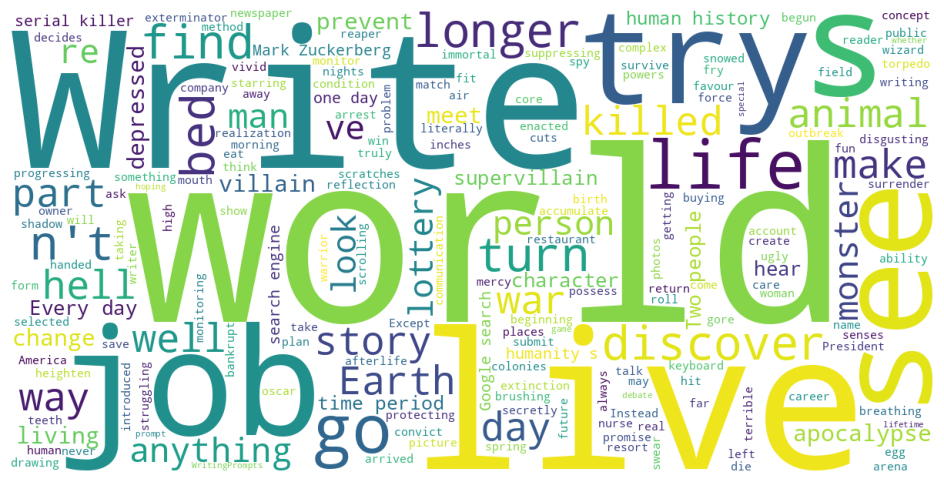

  Saved → hanna_eda_plots/6_prompt_wordcloud.png


In [71]:
prompt_diversity(stories)

In [72]:
metric_summary = metric_correlations(metrics)


[Step 7] Automatic metrics
                Metric        Mean         Std
63      Text length ¤§  306.620265  170.626022
32             chrF Ξ§   31.084209   24.231487
6              BLEU Ξ§    9.753056   28.544859
215     Llama-13B SU 3    3.527778    0.645348
203     Llama-13B CX 1    3.526515    0.698861
207     Llama-13B EM 2    3.341856    0.729288
200     Llama-13B EM 1    3.227286    0.838438
198     Llama-13B RE 1    3.211711    0.831805
79          Human 1 CH    3.210227    1.368383
103     Human Avg 2 CH    3.205019    0.936357
91          Human 3 CH    3.199811    1.360579
1            Coherence    3.149621    0.751348
210     Llama-13B CX 2    3.134628    0.787836
109     Human Avg 3 CH    3.124527    0.969895
97      Human Avg 1 CH    3.119318    0.935650
159  OrcaPlatypus SU 3    3.114804    0.836504
205     Llama-13B RE 2    3.103851    0.801441
214     Llama-13B EM 3    3.093434    0.726123
204    Llama-13B AVG 1    3.092163    0.500697
201     Llama-13B SU 1    3.0710

## Troubleshoot stuff

In [47]:
counts = (
    annotations.groupby("Story ID")
    .size()
)

print(counts.describe())

print(
    counts.value_counts()
    .sort_index()
)

count    1056.0
mean        3.0
std         0.0
min         3.0
25%         3.0
50%         3.0
75%         3.0
max         3.0
dtype: float64
3    1056
Name: count, dtype: int64


In [49]:
annotations[CRITERIA].isna().sum()

,0
Relevance,0
Coherence,0
Empathy,0
Surprise,0
Engagement,0
Complexity,0


In [54]:
print(annotations["Worker ID"].nunique())
annotations.groupby("Worker ID").size().describe()

22


,0
count,22.000000
mean,144.000000
std,290.861446
min,1.000000
25%,2.250000
50%,6.000000
75%,82.250000
max,942.000000
